**Natural Language Processing (NLP) Notenook**

Using LSTM for Time Series Data





---


Loding the Dataset & general imports

In [1]:
# Importing the libraries

# Libraries for handling data and calculating mathematical operations
import numpy as np
import pandas as pd

# Charting library
import matplotlib.pyplot as plt

# To transform the data to a specific range (between 0 and 1) to facilitate model training
from sklearn.preprocessing import MinMaxScaler

# To measure the error between predictions and actual values
from sklearn.metrics import mean_squared_error

# (keras , tensorflow) Libraries for building and training neural models such as LSTM and RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , LSTM, Dropout, Bidirectional
from tensorflow.keras.optimizers import SGD
from tensorflow.random import set_seed

import tensorflow as tf
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense

# Set a fixed value for the seed => to ensure that the code can be rerun with the same results
set_seed(455)
np.random.seed(455)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mastercard_stock_history.csv to Mastercard_stock_history.csv


The dataset is Mastercard's stock price history

In [3]:
# Load data from a CSV file. Mastercard stock price data is loaded,
# with the Date column selected as the index and converted to a date.
dataset = pd.read_csv("Mastercard_stock_history.csv", index_col="Date", parse_dates=["Date"])
# Delete unimportant columns such as dividends and stock splits
dataset = dataset.drop(["Dividends", "Stock Splits"], axis=1)
# Display the first 5 rows of data:
print(dataset.head())


                Open      High       Low     Close     Volume
Date                                                         
2006-05-25  3.748967  4.283869  3.739664  4.279217  395343000
2006-05-26  4.307126  4.348058  4.103398  4.179680  103044000
2006-05-30  4.183400  4.184330  3.986184  4.093164   49898000
2006-05-31  4.125723  4.219679  4.125723  4.180608   30002000
2006-06-01  4.179678  4.474572  4.176887  4.419686   62344000


Data includes stock prices (open, high, low, close) and trading volume for each day

In [4]:
print(dataset.describe())

              Open         High          Low        Close        Volume
count  3872.000000  3872.000000  3872.000000  3872.000000  3.872000e+03
mean    104.896814   105.956054   103.769349   104.882714  1.232250e+07
std     106.245511   107.303589   105.050064   106.168693  1.759665e+07
min       3.748967     4.102467     3.739664     4.083861  6.411000e+05
25%      22.347203    22.637997    22.034458    22.300391  3.529475e+06
50%      70.810079    71.375896    70.224002    70.856083  5.891750e+06
75%     147.688448   148.645373   146.822013   147.688438  1.319775e+07
max     392.653890   400.521479   389.747812   394.685730  3.953430e+08


Descriptive statistics for data such as minimum (min), maximum (max), mean (mean) and standard deviation (std) for different columns

In [5]:
dataset.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


 check for any missing values ​​in the data. The results show that all columns contain zero missing values, meaning the data is complete and contains no blank cells



---
Note :

This will be a (Sequential Problem) meaning :
making a series of decisions over time ...

Historical price data will be used to make future predictions, meaning I'll use past data (such as past stock prices) to predict future prices

Typically, these types of problems deal with time series, where the data relates to time and follows a specific sequence.




---




Plot a graph displaying stock price data (specifically the high prices, 'High') over a specific time period and compare it to a subsequent period




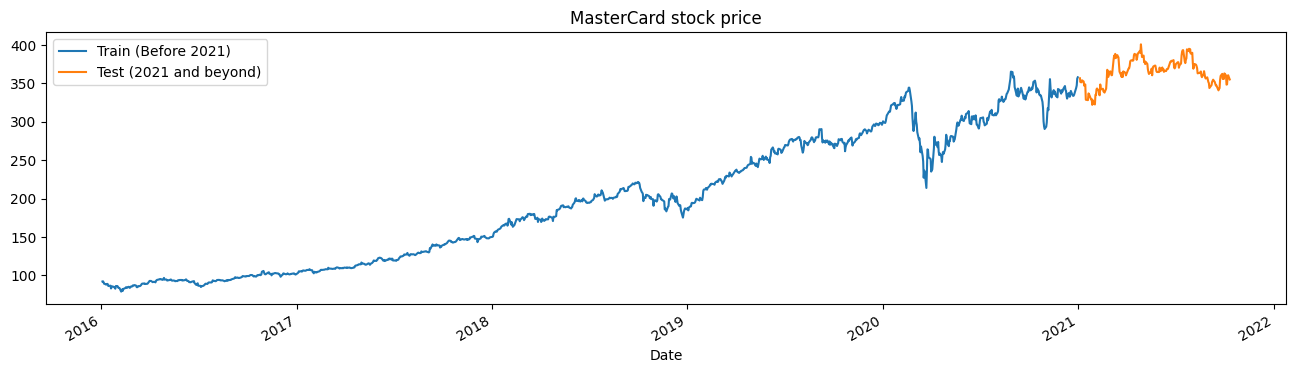

In [6]:
# Specify the start and end of the time period
tstart = 2016
tend = 2020

# train_test_splot function : plotting two sections of data =>
# The time period between tstart and tend
# The period following the year tend+1
def train_test_plot(dataset, tstart, tend):
  # Plots data for the period from 2016 to 2020
  dataset.loc[f'{tstart}':f'{tend}','High'].plot(figsize=(16, 4), legend=True)
  # Plots data from the year after 2020 (i.e. 2021 and beyond).
  dataset.loc[f'{tend+1}':,'High'].plot(figsize=(16, 4), legend=True)
  plt.legend([f'Train (Before {tend+1})', f'Test ({tend+1} and beyond)'])
  plt.title('MasterCard stock price')
  plt.show()

train_test_plot(dataset,tstart,tend)

Blue: Represents data for the training period from 2016 to 2020

Orange: Represents data for the probationary period (2021 and beyond)

In [7]:
def train_test_split(dataset, tstar, tend):
  train = dataset.loc[f'{tstart}':f'{tend}', 'High'].values
  test = dataset.loc[f'{tend+1}':, 'High'].values
  return train, test
training_set, test_set = train_test_split(dataset, tstart, tend)

**train_test_split :**

* Splits the data into two sets :

   1. train : Contains the values of the 'High' column for the period between tstart and tend
   2. test : Contains the values of the 'High' column for the period starting from the year tend+1 and beyond

*   The function returns two arrays : train and test

**Example** : if the date spans from 2016 to 2020, the training data will include these years, while the test data stars from 2021


In [8]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)


Convert data values ​​to be between 0 and 1 using **MinMaxScaler**

=> This is important because it helps the model (such as an LSTM) learn faster and more accurately, because small, uniform values ​​are easier for the model to process than large, disparate values

What does **reshape(-1, 1)** mean?

Reshape is used to change the shape of an array (numpy array) ,

✅ -1 means:
"Leave this dimension to be calculated automatically based on the size of the data."

✅ 1 means:
"Leave each row to contain only one element (meaning one column)."

LSTM expects the data to be 3D, so we Preparing for it



In [9]:
def split_sequence(sequence, n_steps):
  X,y = list(), list()
  for i in range(len(sequence)):
    end_ix = i + n_steps
    if end_ix > len(sequence)-1:
      break
    seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
    X.append(seq_x)
    y.append(seq_y)
  return np.array(X), np.array(y)

n_steps = 60
features = 1
# split into samples
X_train, y_train = split_sequence(training_set_scaled, n_steps)

✅ What is the purpose of this function : **split_sequence** ?


LSTMs can't process the entire sequence at once, so we need to divide it into small time slices (windows)

Each slice (window) contains n_steps of previous values ​​(e.g., 60 days ago), and the goal is to predict the value that follows that slice

📌example:

If we have the chain :

[1, 2, 3, 4, 5, 6]

n_steps = 3

It will turn into:

X: [[1, 2, 3], [2, 3, 4], [3, 4, 5]]

Y: [4, 5, 6]

This means:

The model learns: If you see 1, 2, 3 → you should expect 4, and so on



---


Applying the function to the data

We take every 60 consecutive values ​​(say 60 days of prices), and let the model learn from them to predict the next day



---

**Finalize the data format**

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], features)

✅ Why?

Because the LSTM model predicts 3D data as follows:

**Dimension** | **What does it represent?**

1 | Number of samples (e.g., the number of time periods we divided)

2 | Number of time steps (n_steps = 60)

3 | Number of features (features = 1)


---



🎯 The final result of these codes:

Taking historical stock market data.

Converting it to values ​​between 0 and 1 (scaling).

Dividing it into small 60-day chunks.

Preparing the data appropriately for LSTM.

Goal: Train a model that predicts the next price based on the previous 60 days.


---



Reshape the training data to the desired format for the LSTM model:

(number_of_samples, number_of_timesteps = 60, number_of_features = 1)

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], features)



---
**Sliding Window Fashion**

It is a method of dividing time series (such as stock prices) into small samples so that the model learns from a series of consecutive values ​​and predicts the next value

**📦 Simple example:**

I have a price list: [1, 2, 3, 4, 5, 6, 7]

assume I'am using a 3-value window

The Sliding Window will divide it like this:

**X (inputs)** | **y (expected output)**

[1, 2, 3] |	  4

[2, 3, 4] |	  5

[3, 4, 5]	|  6

[4, 5, 6]	|  7



---

 **This is how the Sliding Window works**

Each time, it takes n_steps of values ​​and uses them as x

The value immediately after that is y

The process is repeated by gradually sliding the window step by step




---


**Building the model**

In [11]:
# The LSTM architecture
model_lstm = Sequential()
model_lstm.add(LSTM(units=125, activation='tanh', input_shape=(n_steps, features)))
model_lstm.add(Dense(units=1))
# Compiling the model
model_lstm.compile(optimizer='RMSprop', loss='mse')

# View form summary
model_lstm.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 125)                 │          63,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             126 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

🔹 Sequential()

A type of model that builds the network sequentially (layer by layer)

🔹 LSTM(units=125, activation="tanh", input_shape=(n_steps, features))

This is the main layer:

LSTM: Long short memory cell (for processing temporal data)

units=125: means there are 125 LSTM cells or units

activation="tanh": The activation function used within the cell

input_shape=(60, 1): means we feed the model a 60-day (time step) with a single feature (such as the closing price only)

🔹 Dense(units=1)

Only one output layer because it is a single-point prediction problem (such as predicting the next day's price)


---

optimizer="RMSprop": A good optimization algorithm for handling temporal data

loss="mse": The MSE error function, commonly used in numerical prediction (regression) problems


---
 What do the numbers mean?

63,500: The number of parameters that can be learned within the LSTM layer

126: Dense layer parameters (associating 125 LSTM outputs into a single output)

None: The number of samples is not predetermined (it will vary depending on the size of the training data)


📌 Conclusion:

WE have now created an LSTM model consisting of:

An LSTM layer that attempts to learn the temporal relationships between stock prices.

A Dense output layer that predicts the next price.

The model is now ready to be trained on our existing data.

In [12]:
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32)
# Parameters :
# X_train: The data entered into the model (60 days for each sample)
# y_train: The value the model is supposed to learn to predict (the price after 60 days)
# epochs=20: Means the model will run through the entire data 20 times
# batch_size=32: Instead of the model running through all the data at once, it is divided into batches
# Each batch contains 32 samples, and the model updates its weights after each batch

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0326
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0017
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0016
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0012
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0011
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0010
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 8.9878e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 7.9797e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 7.4479e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 6.6758e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 7.9274e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 7.0761e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 6.7261e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 6.3797e-04
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 

What's happening here? 🙄

The line of code above, trains the model on the data, learning the relationship between the previous 60 days (X) and the following price (Y)


---



In [14]:
# Prepare test data
dataset_total = dataset.loc[:,'High']
inputs = dataset_total[len(dataset_total) - len(test_set) - n_steps :].values
inputs = inputs.reshape(-1, 1)
# scaling
inputs = sc.transform(inputs)

# split into samples
# Apply a sliding window to test data
X_test, y_test = split_sequence(inputs, n_steps)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], features)
"""

 Exactly like training:

Split the values ​​into windows (x) and projections (y)

Reshape them into a 3D shape
"""

# prediction
predicted_stock_price = model_lstm.predict(X_test)

print(predicted_stock_price.shape[:-1])

# The model makes price predictions based on the test data
# The result is an array of predicted values ​​(195-day forecast) : It means the model gave 195 expected values ​​(which exactly matches the number of y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
(195,)


**Plotting the results:**

In [16]:
def plot_predictions(test, predicted):
   plt.plot(test, color="gray", label="Real")
   plt.plot(predicted, color="red", label="Predicted")
   plt.title("MasterCard Stock Price Prediction")
   plt.xlabel("Time")
   plt.ylabel("MasterCard Stock Price")
   plt.legend()
   plt.show()

# Error calculation (RMSE)
def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))

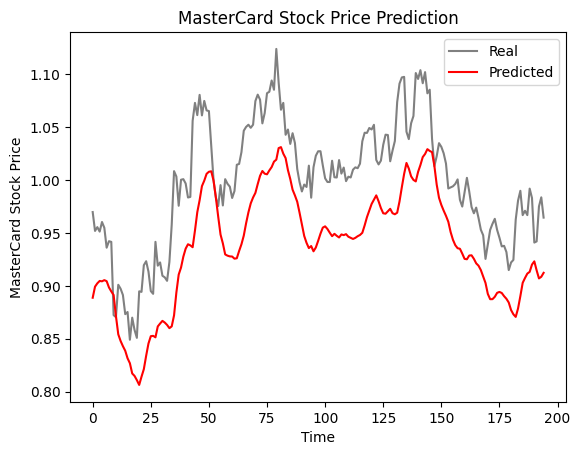

In [17]:
plot_predictions(y_test, predicted_stock_price)

**What does this do?**

It draws two lines:

Gray = True values ​​from the test data (y_test)

Red = Predicted values ​​from the model (predicted_stock_price)


---
 **Evaluation Summary:**

**Aspect | 	Evaluation**

Tracking general trends |	Good

Accuracy of predicted values |	 Some noticeable gaps

Numerical evaluation (RMSE)	| Can be improved by	More data, increasing epochs, or adding another layer



In [18]:
return_rmse(y_test, predicted_stock_price)


The root mean squared error is 0.06.
